In [1]:
import os
import sys
import argparse

import numpy as np
import matplotlib.pyplot as plt

import torch

import dolfinx
import dolfinx.fem.petsc
import ufl
from mpi4py import MPI
import basix.ufl

repo_path = os.path.abspath(os.path.join(os.getcwd(), "../../"))
sys.path.append(repo_path)

from utils import load_yaml, load_pkl, load_npy, format_elapsed_time, timing, plot_complex_valued_function, plot_real_valued_function, evaluate_expression

from scifem import create_real_functionspace

import torch
import torch.nn as nn
import torch.nn.init as init
import numpy as np
from petsc4py import PETSc
import scifem


from utils import project, norm_L2, convert_petsc_mat_to_torch_sparse_coo_tensor, convert_weight_to_tensor
from typing import Optional
import pickle
import time
from tqdm import tqdm
import matplotlib.ticker as ticker

from data_generation.differential_equations import ElasticityLeastSquares


----------------------------------------
2025-10-15 23:37:31 - Start Program
----------------------------------------


In [2]:
mesh_config_path= repo_path + "/configs/elasticity/config_data/config_mesh.yaml"
function_space_config_path= repo_path + "/configs/elasticity/config_data/config_function_space.yaml"
output_reduced_basis_config_path= repo_path + "/configs/elasticity/config_data/config_output_reduced_basis.yaml"
train_dataset_path = repo_path + "/results/elasticity/train_dataset"
test_dataset_path = repo_path + "/results/elasticity/test_dataset"

mesh_args = load_yaml(mesh_config_path)
function_space_args = load_yaml(function_space_config_path)
output_reduced_basis_args = load_yaml(output_reduced_basis_config_path)

In [3]:
print(f'mesh args: {mesh_args}')
print(f'function space args: {function_space_args}')
print(f'output reduced basis args: {output_reduced_basis_args}')

mesh args: {'lower_left_x': 0.0, 'lower_left_y': 0.0, 'upper_right_x': 2.0, 'upper_right_y': 1.0, 'num_x': 128, 'num_y': 64, 'mesh_cell_type': 'triangle'}
function space args: {'p': {'family': 'CG', 'degree': 1}, 'u': {'family': 'CG', 'degree': 2}, 'sigma': {'family': 'RT', 'degree': 2}, 'w': {'family': 'CG', 'degree': 2}, 'q': {'family': 'CG', 'degree': 2}}
output reduced basis args: {'num_evals': 1000, 'num_basis': 512}


In [4]:
mesh_args['num_x'] = 256
mesh_args['num_y'] = 128 
function_space_args['u']['degree'] = 2
function_space_args['sigma']['degree'] = 2
function_space_args['w']['degree'] = 2 
function_space_args['q']['degree'] = 2

In [5]:
num_samples = 101

if mesh_args['num_x'] == 128:
    p_dof = load_npy(train_dataset_path+'/p_dof.npy')[:num_samples]
elif mesh_args['num_x'] == 256:
    p_dof = load_npy(train_dataset_path+'/p_dof_256x128.npy')[:num_samples]
else:
    raise ValueError(f"Unsupported mesh resolution: {mesh_args['num_x']}")
print(p_dof.shape)

(101, 33153)


In [6]:
elasticity_least_squares = ElasticityLeastSquares(mesh_args, function_space_args)

In [7]:
mesh = elasticity_least_squares.mesh
Vh = elasticity_least_squares.Vh

In [8]:
print(f'# DoFs of sigma_u: {len(dolfinx.fem.Function(Vh['sigma_u']).x.array)}')

# DoFs of sigma_u: 920578


In [9]:
sigma_u_dim = dolfinx.fem.Function(elasticity_least_squares.Vh['sigma_u']).x.array.shape[0]
sigma_dim = dolfinx.fem.Function(elasticity_least_squares.Vh['sigma']).x.array.shape[0]
u_dim = dolfinx.fem.Function(elasticity_least_squares.Vh['u']).x.array.shape[0]

dtype = 'float64'

sigma_u_dof = np.zeros((num_samples, sigma_u_dim), dtype=dtype)
sigma_dof = np.zeros((num_samples, sigma_dim), dtype=dtype)
u_dof = np.zeros((num_samples, u_dim), dtype=dtype)

solve_PDE_time = []
for i in tqdm(range(num_samples)):
    p = dolfinx.fem.Function(elasticity_least_squares.Vh['p'], dtype=dtype)
    p.x.array[:] = p_dof[i,:]
    
    start_time = time.time()
    sigma_u = elasticity_least_squares.solve_sigma_u(p=p)
    end_time = time.time()
    solve_PDE_time.append(end_time - start_time)

    sigma = sigma_u.sub(0).collapse()
    u = sigma_u.sub(1).collapse()

    sigma_u_dof[i] = sigma_u.x.array
    sigma_dof[i] = sigma.x.array
    u_dof[i] = u.x.array

100%|██████████| 101/101 [24:45<00:00, 14.71s/it]


In [10]:
print(f'sigma_u_dim: {sigma_u_dim}')
print(f'avg solve time: {np.mean(solve_PDE_time[1:]):.2f} seconds | std: {np.std(solve_PDE_time[1:]):.5f}')

sigma_u_dim: 920578
avg solve time: 14.62 seconds | std: 0.09646


In [11]:
torch_dtype = {
    'float16': torch.float16,
    'float32': torch.float32,
    'float64': torch.float64,
}

In [12]:
weight_matrices_assemble_time = []
reference_loss_list = []
num_samples_for_reference_loss = num_samples
for i in tqdm(range(num_samples_for_reference_loss)):
    p_fc = dolfinx.fem.Function(Vh['p'])
    p_fc.x.array[:] = p_dof[i]

    start_time = time.time()
    weight = elasticity_least_squares.compute_weight(p_fc)
    end_time = time.time()
    weight_matrices_assemble_time.append(end_time - start_time)

    weight_tensor = convert_weight_to_tensor(weight, dtype=torch_dtype['float64'])

    y = sigma_u_dof[i] 
    y = torch.tensor(y, dtype=torch_dtype['float64'])
    reference_loss = torch.vdot(y, weight_tensor['A00'] @ y) + 2 * torch.vdot(y, weight_tensor['A01'])  + weight_tensor['A11']
    print(f'reference loss: {reference_loss.item()}')
    reference_loss_list.append(reference_loss.item())

  1%|          | 1/101 [00:14<24:59, 15.00s/it]

reference loss: 0.0001781772294011108


  2%|▏         | 2/101 [00:30<24:53, 15.08s/it]

reference loss: 0.0002396714395596633


  3%|▎         | 3/101 [00:45<24:44, 15.15s/it]

...

reference loss: 0.00034213869062499347


 99%|█████████▉| 100/101 [25:13<00:15, 15.14s/it]

reference loss: 0.00010598675693074266


100%|██████████| 101/101 [25:28<00:00, 15.13s/it]

reference loss: 0.00025338890239817724


In [13]:
print(f"reference loss mean: {np.mean(reference_loss_list[1:]):.2e}")
print(f"reference loss std: {np.std(reference_loss_list[1:]):.2e}")
print(f"weight matrices assemble time mean: {np.mean(weight_matrices_assemble_time[1:]):.2f}")
print(f"weight matrices assemble time std: {np.std(weight_matrices_assemble_time[1:]):.5f}")

reference loss mean: 2.94e-04
reference loss std: 8.34e-05
weight matrices assemble time mean: 5.57
weight matrices assemble time std: 0.03789


In [14]:
q = elasticity_least_squares.solve_q()
w = elasticity_least_squares.solve_w()

In [15]:
q1, q2 = ufl.split(q)
z1 = ufl.grad(q1)
z2 = ufl.grad(q2)
z = ufl.as_vector([z1, z2])

In [16]:
n = ufl.FacetNormal(mesh)
t = elasticity_least_squares.traction
ds = elasticity_least_squares.ds
mark_id = elasticity_least_squares.mark_id
f = elasticity_least_squares.f()
u0= elasticity_least_squares.u0()

print('Validating auxiliary variables...')
temp1 = dolfinx.fem.assemble_scalar(dolfinx.fem.form(ufl.inner(ufl.div(z), ufl.div(z))*ufl.dx))
print(f'integral ||div(z)||_2^2 dx = {temp1}')

temp2 =  dolfinx.fem.assemble_scalar(dolfinx.fem.form(ufl.inner(ufl.dot(z, n) - t, ufl.dot(z, n) - t) * ds(mark_id["right"])))
print(f'integral ||z dot n - t||_2^2 ds(right) = {temp2}')

temp3 =  dolfinx.fem.assemble_scalar(dolfinx.fem.form(ufl.inner(ufl.dot(z, n), ufl.dot(z, n)) * ds(mark_id["bottom_top"])))
print(f'integral ||z dot n - t||_2^2 ds(bottom & top) = {temp3}')

temp4 =  dolfinx.fem.assemble_scalar(dolfinx.fem.form(ufl.inner(w - u0, w - u0) * ds(mark_id["left"])))
print(f'integral ||w - u0||_2^2 ds(left) = {temp4}')

Validating auxiliary variables...
integral ||div(z)||_2^2 dx = 1.566585248124198e-06
integral ||z dot n - t||_2^2 ds(right) = 5.534678707453591e-10
integral ||z dot n - t||_2^2 ds(bottom & top) = 5.23835988146338e-10
integral ||w - u0||_2^2 ds(left) = 0.0


In [17]:
sigma1, sigma2 = ufl.split(sigma)
sigma_ = ufl.as_vector([sigma1, sigma2])

In [18]:
print('Validating sigma_u variables...')
temp5 = dolfinx.fem.assemble_scalar(dolfinx.fem.form(ufl.inner(ufl.div(sigma_) + f, ufl.div(sigma_) + f)*ufl.dx))
print(f'integral ||div(sigma) + f||_2^2 dx = {temp5}')

temp6 =  dolfinx.fem.assemble_scalar(dolfinx.fem.form(ufl.inner(ufl.dot(sigma_, n), ufl.dot(sigma_, n)) * ds(mark_id["right"])))
print(f'integral ||sigma dot n - 0||_2^2 ds(right) = {temp6}')

Validating sigma_u variables...
integral ||div(sigma) + f||_2^2 dx = 7.169185100184071e-07
integral ||sigma dot n - 0||_2^2 ds(right) = 4.7309105314509717e-32


In [19]:
def compute_physical_loss_1(sigma_fc, u_fc, z_fc, w_fc, p_fc):
    def get_lame_parameters(p: dolfinx.fem.Function):
        mesh = p.function_space.mesh

        E_0 = 1.0  
        nu = 0.4 # Poisson ratio
        E = dolfinx.fem.Constant(mesh, dolfinx.default_scalar_type(E_0)) + ufl.exp(p) # Young's modulus
        lambda_ = (E*nu)/((1.0+nu)*(1.0-2.0*nu)) #  Lamé’s first parameter
        mu = E/(2.0*(1.0+nu)) #  Lamé’s second parameter

        return lambda_, mu

    def C_inv_action(sigma):
        result = 1/(2*mu) * sigma
        result -=  lambda_/(4*mu*(lambda_+mu)) * ufl.tr(sigma) * ufl.Identity(2)
        return result

    def C_action(epsilon): 
        result = 2*mu*epsilon
        result += lambda_ * ufl.tr(epsilon) * ufl.Identity(2)
        return result

    lambda_, mu = get_lame_parameters(p=p_fc)

    epsilon_u_fc = ufl.sym(ufl.grad(u_fc))
    epsilon_w_fc = ufl.sym(ufl.grad(w_fc))

    integral = ufl.inner(sigma_fc + z_fc, C_inv_action(sigma_fc + z_fc)) * ufl.dx
    integral -= ufl.inner(epsilon_u_fc + epsilon_w_fc, sigma_fc + z_fc) * ufl.dx
    integral -= ufl.inner(sigma_fc + z_fc, epsilon_u_fc + epsilon_w_fc) * ufl.dx
    integral += ufl.inner(epsilon_u_fc + epsilon_w_fc, C_action(epsilon_u_fc + epsilon_w_fc)) * ufl.dx

    return dolfinx.fem.assemble_scalar(dolfinx.fem.form(integral))

In [20]:
def asymmetry(sigma):
    e1 = ufl.unit_vector(i=0, d=2)
    e2 = ufl.unit_vector(i=1, d=2)
    result = ufl.inner(sigma[0], -e2) + ufl.inner(sigma[1], e1)
    return result

In [21]:
dolfinx.fem.assemble_scalar(dolfinx.fem.form(ufl.inner(asymmetry(sigma_) + asymmetry(z), asymmetry(sigma_) + asymmetry(z)) * ufl.dx))

4.2576347822998844e-05

In [22]:
x = mesh.geometry.x[:, 0]
y = mesh.geometry.x[:, 1]

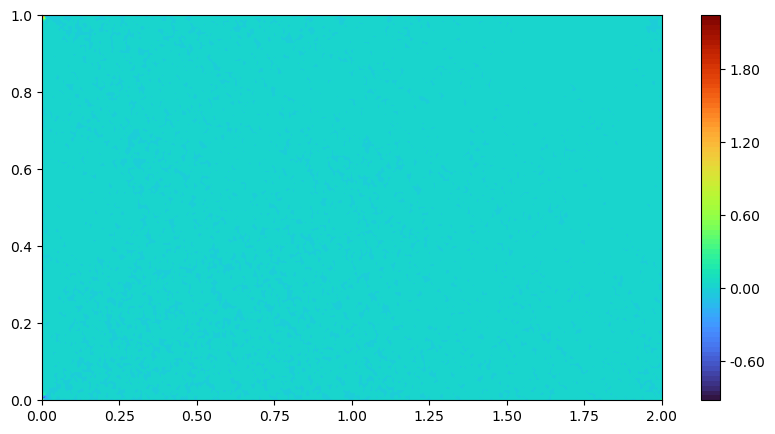

In [23]:
ax = plt.figure(figsize=(10,5))
plt.tricontourf(x, y, evaluate_expression(mesh, asymmetry(sigma_) + asymmetry(z), mesh.geometry.x)[1][:, 0], cmap='turbo', levels=100)
cbar = plt.colorbar()
cbar.ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=6, prune=None))
cbar.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.2f"))
plt.show()

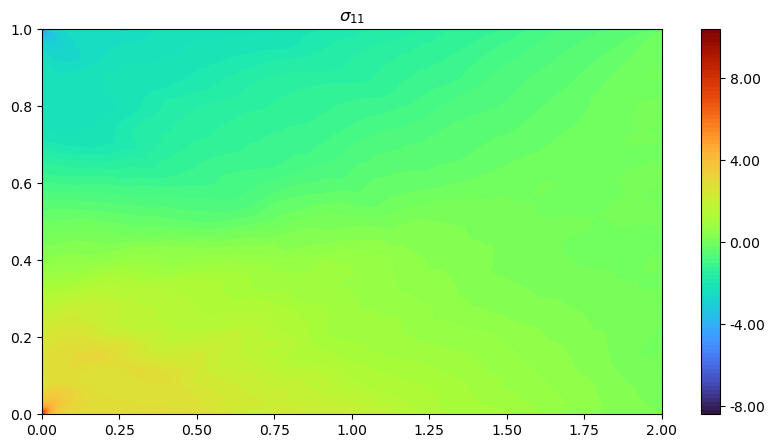

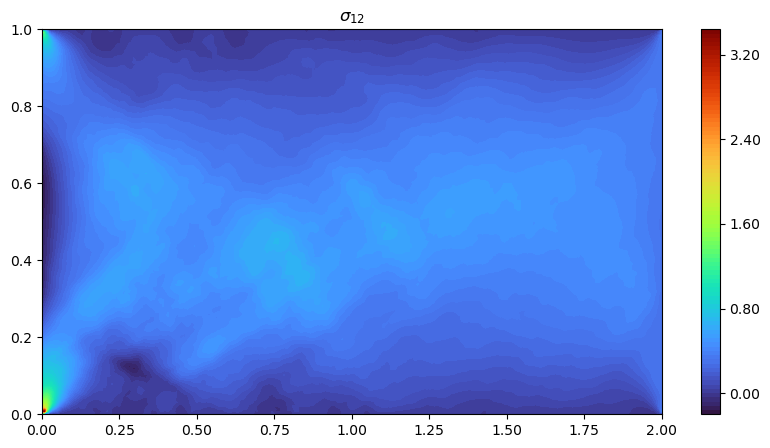

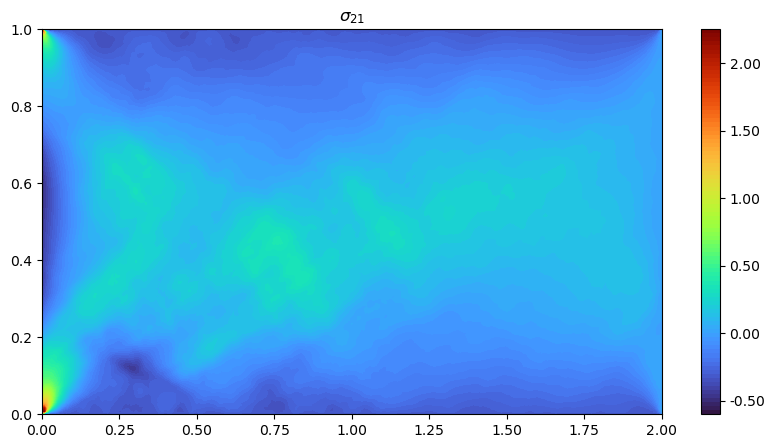

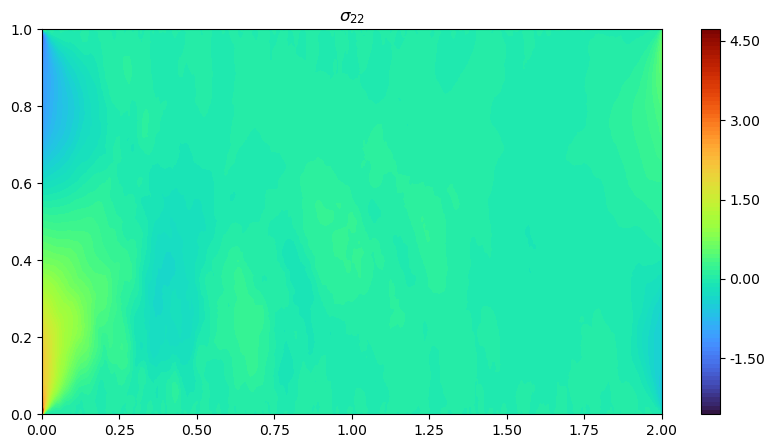

In [24]:
x = mesh.geometry.x[:, 0]
y = mesh.geometry.x[:, 1]

ax = plt.figure(figsize=(10,5))
plt.tricontourf(x, y, evaluate_expression(mesh, sigma, mesh.geometry.x)[1][:, 0], cmap='turbo', levels=100)
cbar = plt.colorbar()
cbar.ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=6, prune=None))
cbar.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.2f"))
plt.title(r"$\sigma_{11}$")
# plt.savefig("sigma_11_elasticity.png", dpi=300, bbox_inches="tight")  # save as PNG
plt.show()


ax = plt.figure(figsize=(10,5))
plt.tricontourf(x, y, evaluate_expression(mesh, sigma, mesh.geometry.x)[1][:, 1], cmap='turbo', levels=100)
cbar = plt.colorbar()
cbar.ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=6, prune=None))
cbar.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.2f"))
plt.title(r"$\sigma_{12}$")
# plt.savefig("sigma_12_elasticity.png", dpi=300, bbox_inches="tight")  # save as PNG
plt.show()


ax = plt.figure(figsize=(10,5))
plt.tricontourf(x, y, evaluate_expression(mesh, sigma, mesh.geometry.x)[1][:, 2], cmap='turbo', levels=100)
cbar = plt.colorbar()
cbar.ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=6, prune=None))
cbar.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.2f"))
plt.title(r"$\sigma_{21}$")
# plt.savefig("sigma_21_elasticity.png", dpi=300, bbox_inches="tight")  # save as PNG
plt.show()
 

ax = plt.figure(figsize=(10,5))
plt.tricontourf(x, y, evaluate_expression(mesh, sigma, mesh.geometry.x)[1][:, 3], cmap='turbo', levels=100)
cbar = plt.colorbar()
cbar.ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=6, prune=None))
cbar.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.2f"))
plt.title(r"$\sigma_{22}$")
# plt.savefig("sigma_22_elasticity.png", dpi=300, bbox_inches="tight")  # save as PNG
plt.show()

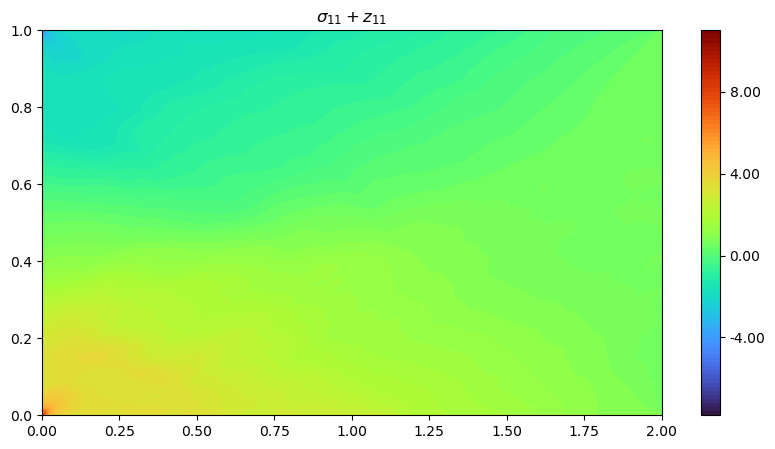

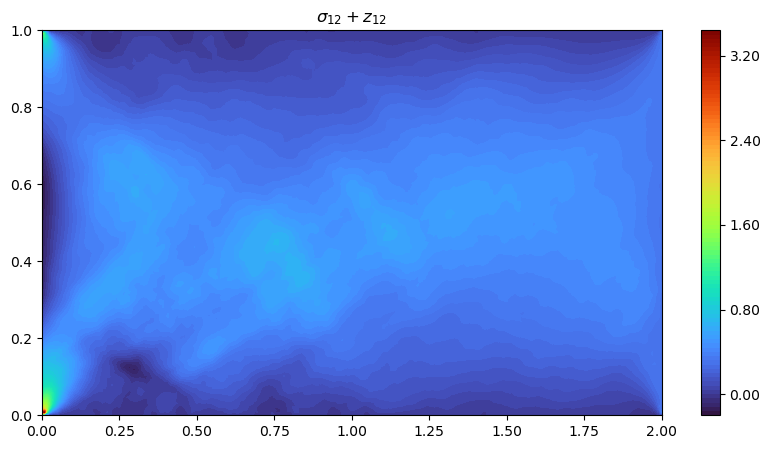

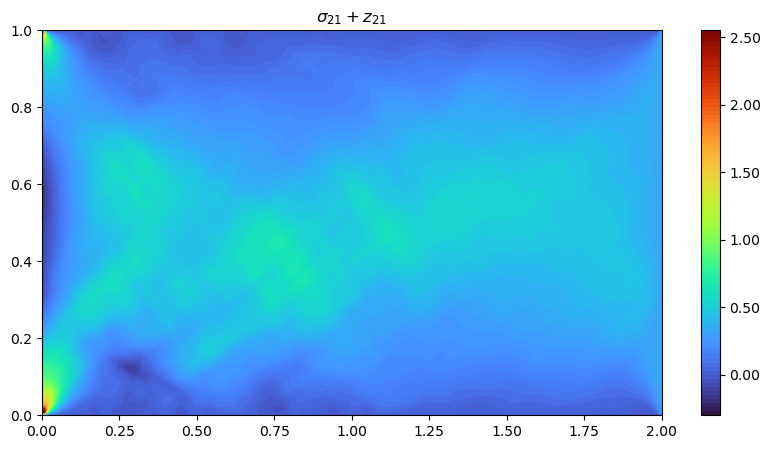

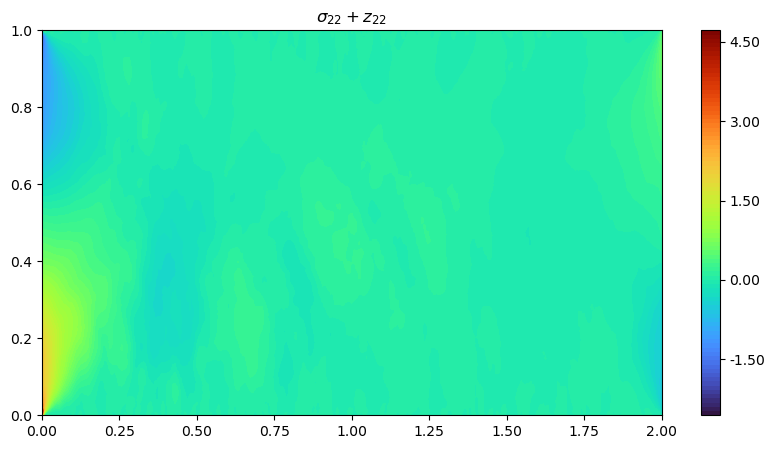

In [25]:
x = mesh.geometry.x[:, 0]
y = mesh.geometry.x[:, 1]


sigma1_z1_evals = evaluate_expression(mesh, sigma1, mesh.geometry.x)[1] + evaluate_expression(mesh, z1, mesh.geometry.x)[1]
sigma2_z2_evals = evaluate_expression(mesh, sigma2, mesh.geometry.x)[1] + evaluate_expression(mesh, z2, mesh.geometry.x)[1]

ax = plt.figure(figsize=(10,5))
plt.tricontourf(x, y, sigma1_z1_evals[:, 0], cmap='turbo', levels=100)
cbar = plt.colorbar()
cbar.ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=6, prune=None))
cbar.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.2f"))
plt.title(r"$\sigma_{11} + z_{11}$")
plt.show()

# # Compute shared limits
# vmin = -0.5
# vmax = 2.5

ax = plt.figure(figsize=(10,5))
plt.tricontourf(x, y, sigma1_z1_evals[:, 1], cmap='turbo', levels=100)
cbar = plt.colorbar()
cbar.ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=6, prune=None))
cbar.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.2f"))
plt.title(r"$\sigma_{12} + z_{12}$")
plt.show()


ax = plt.figure(figsize=(10,5))
plt.tricontourf(x, y, sigma2_z2_evals[:, 0], cmap='turbo', levels=100)
cbar = plt.colorbar()
cbar.ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=6, prune=None))
cbar.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.2f"))
plt.title(r"$\sigma_{21} + z_{21}$")
plt.show()


# # Create subplots
# fig, axs = plt.subplots(1, 2, figsize=(16, 5), constrained_layout=True)

# # Plot first field
# cs1 = axs[0].tricontourf(x, y, sigma1_z1_evals[:, 1], cmap='turbo', levels=500, vmin=vmin, vmax=vmax)
# axs[0].set_title(r"$\sigma_{12} + z_{12}$")

# # Plot second field
# cs2 = axs[1].tricontourf(x, y, sigma2_z2_evals[:, 0], cmap='turbo', levels=500, vmin=vmin, vmax=vmax)
# axs[1].set_title(r"$\sigma_{21} + z_{21}$")


# # Shared colorbar
# cbar = fig.colorbar(cs1, ax=axs, orientation='vertical', fraction=0.02, pad=0.04)
# cbar.ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=6, prune=None))
# cbar.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.2f"))

# plt.show()

# ax = plt.figure(figsize=(10,5))
# plt.tricontourf(x, y, sigma1_z1_evals[:, 1] - sigma2_z2_evals[:, 0], cmap='turbo', levels=100)
# cbar = plt.colorbar()
# cbar.ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=6, prune=None))
# cbar.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.2f"))
# plt.title(r"$\sigma_{12} + z_{12} - \sigma_{21} - z_{21}$")
# plt.show()

ax = plt.figure(figsize=(10,5))
plt.tricontourf(x, y, sigma2_z2_evals[:, 1], cmap='turbo', levels=100)
cbar = plt.colorbar()
cbar.ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=6, prune=None))
cbar.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.2f"))
plt.title(r"$\sigma_{22} + z_{22}$")
plt.show()